# Clasificación de perros y gatos con Keras

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/dogs/dog.4329.jpg
/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/dogs/dog.4223.jpg
/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/dogs/dog.4253.jpg
/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/dogs/dog.4190.jpg
/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/dogs/dog.4354.jpg
/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/dogs/dog.4136.jpg
/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/dogs/dog.4226.jpg
/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/dogs/dog.4214.jpg
/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/dogs/dog.4888.jpg
/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/dogs/dog.4170.jpg
/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/dogs/dog.4323.jpg
/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/dogs/dog.4262.jpg
/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/dogs/dog.4788.jpg
/kaggle/input/dl-cats-vs-dogs/dataset_

Step 2: Preprocessing and Loading Data

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an ImageDataGenerator for rescaling images
datagen = ImageDataGenerator(rescale=1.0/255.0)

# Load training data
train = datagen.flow_from_directory(
    directory='/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/train/',
    target_size=(150, 150),
    color_mode="rgb",
    batch_size=32,
    class_mode="binary"
)

# Load test data
test = datagen.flow_from_directory(
    directory='/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/',
    target_size=(150, 150),
    color_mode="rgb",
    batch_size=32,
    class_mode="binary"
)

Found 8000 images belonging to 2 classes.
Found 1999 images belonging to 2 classes.


Step 3: Build the CNN Model

Includes convolutional layers, max-pooling, and fully connected layers.

In [3]:
from keras.models import Sequential
from keras.layers import Conv2D, Dropout, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam

# Initialize the model
classifier = Sequential()

# Convolution layer 1
classifier.add(Conv2D(32, (3, 3), input_shape=(150, 150, 3), activation='relu', padding='same'))
classifier.add(MaxPooling2D(strides=(2,2), pool_size=(2, 2)))

# Convolution layer 2
classifier.add(Conv2D(64, (3, 3), activation='relu'))
classifier.add(MaxPooling2D(strides=(2,2), pool_size=(2, 2)))

# Convolution layer 3
classifier.add(Conv2D(64, (3, 3), activation='relu'))
classifier.add(MaxPooling2D(strides=(2,2), pool_size=(2, 2)))

# Convolution layer 4
classifier.add(Conv2D(128, (3, 3), activation='relu'))
classifier.add(MaxPooling2D(strides=(2,2), pool_size=(2, 2)))

# Flatten the results from convolutional layers
classifier.add(Flatten())

# Fully connected layer
classifier.add(Dense(units=600, activation='relu'))
classifier.add(Dropout(0.5))

# Output layer
classifier.add(Dense(units=1, activation='sigmoid'))

# Compile the model
classifier.compile(optimizer=Adam(learning_rate=0.0003), loss='binary_crossentropy', metrics=['accuracy'])

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 4: Train the Model and graph the training process

Epoch 1/5


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1731930486.404544     120 service.cc:145] XLA service 0x79bf580043d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731930486.404623     120 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1731930486.404631     120 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


  1/250 ━━━━━━━━━━━━━━━━━━━━ 37:13 9s/step - accuracy: 0.5938 - loss: 0.6835

I0000 00:00:1731930492.167998     120 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 207ms/step - accuracy: 0.5365 - loss: 0.6876 - val_accuracy: 0.6815 - val_loss: 0.6011
Epoch 2/5


/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.7333 - val_loss: 0.6420
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.6743 - loss: 0.5937 - val_accuracy: 0.7293 - val_loss: 0.5356
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 132us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.8000 - val_loss: 0.5080
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.7307 - loss: 0.5289 - val_accuracy: 0.7707 - val_loss: 0.4798


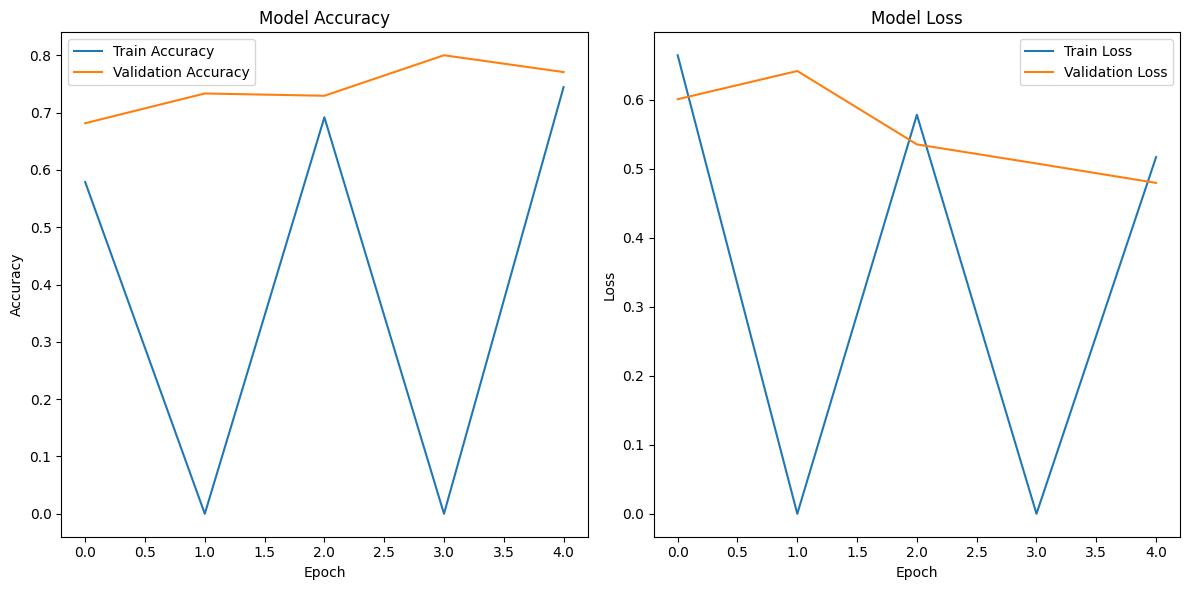

In [4]:

# Train the model and capture the history
history = classifier.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    epochs=5,
    validation_data=test,
    validation_steps=test.samples // test.batch_size
)

# Plotting training & validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='best')

# Show the plot
plt.tight_layout()
plt.show()

In [7]:
# Modelo de clasificacion CNN

classifier = Sequential()


## convolucion #1
classifier.add(Conv2D(32, (3, 3), input_shape = (150, 150, 3), activation = 'relu', padding='same'))
classifier.add(MaxPooling2D(strides=(2,2), pool_size = (2, 2)))

## convolucion #2
classifier.add(Conv2D(64, (3, 3), activation = 'relu'))
classifier.add(MaxPooling2D(strides=(2,2), pool_size = (2, 2)))

## convolucion #3

classifier.add(Conv2D(64, (3, 3), activation = 'relu'))
classifier.add(MaxPooling2D(strides=(2,2), pool_size = (2, 2)))

## convolucion #4

classifier.add(Conv2D(128, (3, 3), activation = 'relu'))
classifier.add(MaxPooling2D(strides=(2,2), pool_size = (2, 2)))


classifier.add(Flatten())  ### Aplanamos los valores

classifier.add(Dense(units = 600, activation = 'relu'))  ## utilizamos 600 neuronas

classifier.add(Dropout(0.5))
classifier.add(Dense(units = 1, activation = 'sigmoid')) ## capa final sigmoid con una sola neurona

#sgd = SGD(lr=0.1)
classifier.compile(optimizer = Adam(learning_rate=0.0003), loss = 'binary_crossentropy', metrics = ['accuracy'])


classifier.fit(train,
#steps_per_epoch = 8000,
epochs = 25,
validation_data = test,
shuffle = True
#validation_steps = 2000
)

# This take aprox 15 min ! 25 epoch

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 80ms/step - accuracy: 0.5438 - loss: 0.6826 - val_accuracy: 0.6523 - val_loss: 0.6073
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.6982 - loss: 0.5696 - val_accuracy: 0.7279 - val_loss: 0.5306
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.7539 - loss: 0.4964 - val_accuracy: 0.7804 - val_loss: 0.4646
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.7799 - loss: 0.4660 - val_accuracy: 0.7979 - val_loss: 0.4319
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.8210 - loss: 0.4046 - val_accuracy: 0.7954 - val_loss: 0.4400
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.8461 - loss: 0.3574 - val_accuracy: 0.8104 - val_loss: 0.4054
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.8587 - loss: 0.3096 - val_accuracy: 0.8239 - val_loss: 0.3782
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 86ms/step - accuracy: 0.8806 - loss: 0.2789 - 

# Transfer learning
Three models — VGG16, EfficientNet, and ResNet50 — are solid choices, they have different strengths. Here's a comparison:

- VGG16:

Pros: Simple and easy to use. Good baseline for smaller datasets.
Cons: Large number of parameters, which can lead to slower training and high memory usage. It is less efficient than newer models like EfficientNet or ResNet.
Best for: Simpler problems or when you need a straightforward approach.

- EfficientNet:

Pros: Known for being more efficient and achieving state-of-the-art performance with fewer parameters. It's designed to be computationally efficient and can scale well for different problems.
Cons: Slightly more complex than VGG16, but it is still quite efficient.
Best for: Faster training with fewer resources and high accuracy.

- ResNet50:

Pros: Very popular in transfer learning tasks. It’s very deep, yet its residual blocks allow for better learning of deep models. It has shown excellent performance on many tasks, including classification.
Cons: Slightly more computationally intensive than VGG16, but generally faster than VGG16 in practice.
Best for: Deep learning tasks requiring very good performance.

In [8]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
import requests
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO


In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Utilities to inference and evaluation

In [51]:

def test_model_with_url(model, url, target_size=(150, 150), model_type="efficientnet"):
    """
    Tests a given model with an image from a URL.

    Parameters:
    - model: The trained model to test.
    - url: URL of the image to test.
    - target_size: The size to which the image will be resized.
    - model_type: Type of the model, used to apply specific preprocessing.
                  Options: "efficientnet", "vgg16", "resnet50".
    
    Returns:
    - prediction: The model's prediction for the given image.
    """
    try:
        # Download the image
        response = requests.get(url, stream=True)
        response.raise_for_status()  # Raise an error for failed request
        img_bytes = BytesIO(response.content)
        img = load_img(img_bytes, target_size=target_size)
        #img = load_img(response.raw, target_size=target_size)
        
        # Convert to numpy array and preprocess
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        if model_type == "efficientnet":
            img_array = efficientnet_preprocess(img_array)
        elif model_type == "vgg16":
            img_array = vgg16_preprocess(img_array)
        elif model_type == "resnet50":
            img_array = resnet_preprocess(img_array)
        else:
            raise ValueError("Invalid model_type! Use 'efficientnet', 'vgg16', or 'resnet50'.")

        # Predict using the model
        prediction = model.predict(img_array)
        class_labels = ["Thist is a Cat", "This is a DOG!"]  # Replace with your actual class names
        predicted_class = class_labels[int(prediction[0][0] >= 0.5)]
        print(f"Predicted Class as: {predicted_class}")

        # Plot the image
        plt.figure(figsize=(4, 4))
        plt.imshow(img)  # Show the original image
        plt.axis('off')
        plt.title("Input Image")
        plt.show()
        
        return prediction

    except Exception as e:
        print(f"Error processing image from URL: {e}")
        return None


def evaluate_models_on_same_plot(models, model_names, test_data):
    """
    Evaluate multiple models on the same dataset and plot confusion matrices together.
    
    Args:
        models (list): List of trained models.
        model_names (list): List of names for the models.
        test_data: ImageDataGenerator object for the test dataset.
    
    Returns:
        None. Displays confusion matrices and metrics for each model.
    """
    if len(models) != len(model_names):
        raise ValueError("The number of models and model names must match!")
    
    true_labels = test_data.classes  # Ground truth labels
    class_labels = list(test_data.class_indices.keys())  # Class names
    num_models = len(models)
    
    # Set up the figure for multiple confusion matrices
    fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 6))
    if num_models == 1:
        axes = [axes]  # Ensure axes is always a list for consistency
    
    for i, (model, name) in enumerate(zip(models, model_names)):
        # Predict probabilities
        predictions = model.predict(test_data, steps=test_data.samples // test_data.batch_size + 1)
        predicted_labels = (predictions > 0.5).astype(int).flatten()
        
        # Confusion Matrix
        cm = confusion_matrix(true_labels, predicted_labels)
        
        # Metrics
        accuracy = accuracy_score(true_labels, predicted_labels)
        precision = precision_score(true_labels, predicted_labels)
        recall = recall_score(true_labels, predicted_labels)
        f1 = f1_score(true_labels, predicted_labels)
        
        # Plot Confusion Matrix
        ax = axes[i]
        im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
        ax.set_title(f"{name}\nAcc: {accuracy:.2f}, Prec: {precision:.2f}, Rec: {recall:.2f}, F1: {f1:.2f}")
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")
        ax.set_xticks(np.arange(len(class_labels)))
        ax.set_yticks(np.arange(len(class_labels)))
        ax.set_xticklabels(class_labels)
        ax.set_yticklabels(class_labels)

        # Annotate the confusion matrix
        for j in range(cm.shape[0]):
            for k in range(cm.shape[1]):
                ax.text(k, j, format(cm[j, k], 'd'), ha="center", va="center", color="black")
    
    # Adjust layout and add colorbar
    # fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.02, pad=0.08)
    # plt.tight_layout()
    plt.show()



## Preprocessing data

In [10]:
datagen = ImageDataGenerator(rescale=1.0/255.0)

# Load training and test data
train = datagen.flow_from_directory(
    directory='/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/train/',
    target_size=(150, 150),
    color_mode="rgb",
    batch_size=32,
    class_mode="binary"
)

test = datagen.flow_from_directory(
    directory='/kaggle/input/dl-cats-vs-dogs/dataset_dogs_vs_cats/test/',
    target_size=(150, 150),
    color_mode="rgb",
    batch_size=32,
    class_mode="binary"
)

Found 8000 images belonging to 2 classes.
Found 1999 images belonging to 2 classes.


## Efficient Net

Load the pre-trained EfficientNet model without the top layer (to replace it with your own classifier):

In [9]:
# Load the EfficientNetB0 model pre-trained on ImageNet, excluding the top classification layer
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the layers of the pre-trained model
base_model.trainable = False

# Build your own classifier on top
x = base_model.output
x = Flatten()(x)
x = Dense(600, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Combine the base model and the new classifier
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0003), loss='binary_crossentropy', metrics=['accuracy'])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Data Preprocessing with ImageDataGenerator:

Train and Plot the model:

Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 108ms/step - accuracy: 0.5115 - loss: 1.3324 - val_accuracy: 0.4995 - val_loss: 0.6931
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.6000 - val_loss: 0.6930
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - accuracy: 0.5011 - loss: 0.6937 - val_accuracy: 0.5005 - val_loss: 0.6931


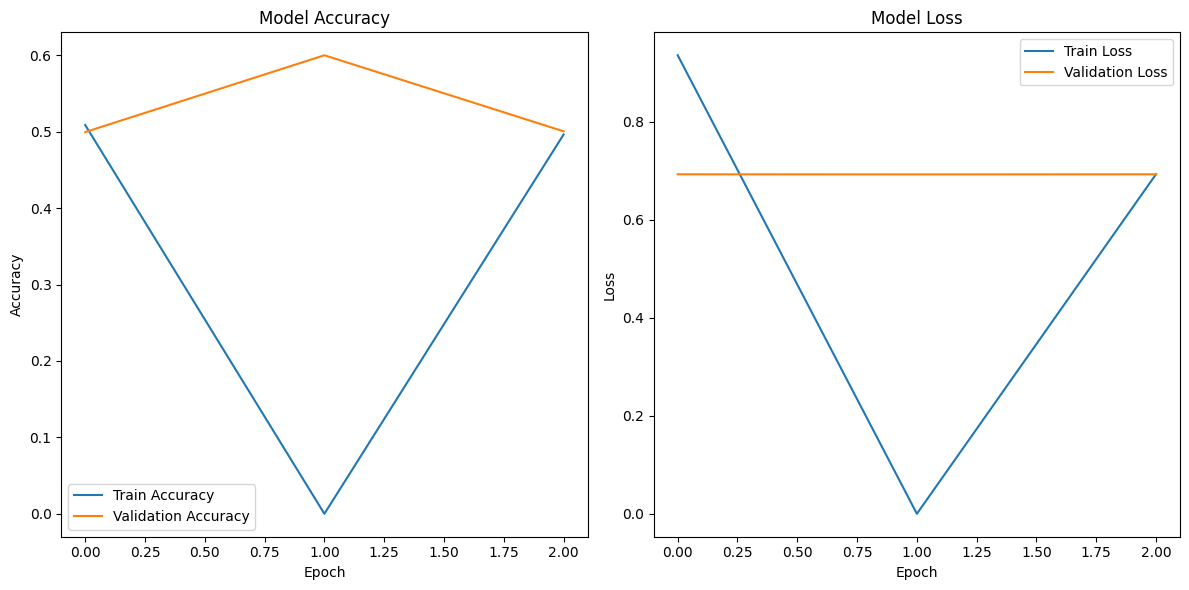

In [11]:
# Train the model and capture the history
history = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    epochs=3,
    validation_data=test,
    validation_steps=test.samples // test.batch_size
)

# Plotting training & validation accuracy
plt.figure(figsize=(12, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='best')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')

# Show the plot
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted Class as: This is a DOG!


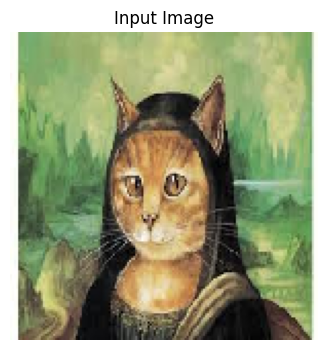

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted Class as: This is a DOG!


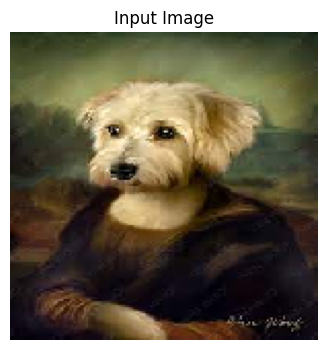

array([[0.99998796]], dtype=float32)

In [40]:
url_test1_cat = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRHZMzqD0FsWs0Os0j5Xos1PvGmr79lWKL96w&s'
urt_test1_dog = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQw4tt3Zfl6NP6_l3JhHcM9OvHhaW9rq_cXFRjeYmTakhTA_0TC4b-6LTutrVRkXyhSq8E&usqp=CAU'
test_model_with_url(model, url_test1_cat, target_size=(150, 150), model_type="efficientnet")
test_model_with_url(model, urt_test1_dog, target_size=(150, 150), model_type="efficientnet")

Switching Models:

If you want to use ResNet50 or VGG16 instead, simply replace EfficientNetB0 with ResNet50 or VGG16, and ensure that you use the correct input shape.

## RESNET 50

In [41]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the layers of the pre-trained model
base_model.trainable = False

# Build your own classifier on top
x = base_model.output
x = Flatten()(x)
x = Dense(600, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Combine the base model and the new classifier
model_resnet = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model_resnet.compile(optimizer=Adam(learning_rate=0.0003), loss='binary_crossentropy', metrics=['accuracy'])

Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 132ms/step - accuracy: 0.5455 - loss: 0.8048 - val_accuracy: 0.5978 - val_loss: 0.6668
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.6667 - val_loss: 0.5947
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - accuracy: 0.5995 - loss: 0.6608 - val_accuracy: 0.6058 - val_loss: 0.6568


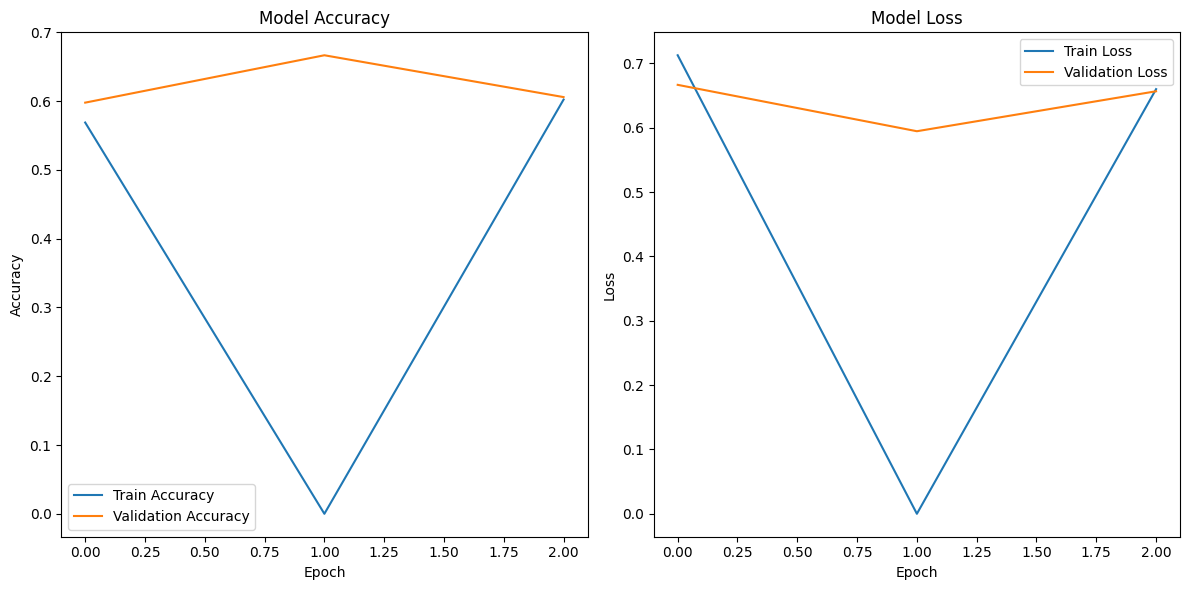

In [42]:
# Train the model and capture the history
history_resnet = model_resnet.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    epochs=3,
    validation_data=test,
    validation_steps=test.samples // test.batch_size
)

# Plotting training & validation accuracy
plt.figure(figsize=(12, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='best')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'], label='Train Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')

# Show the plot
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Class as: This is a DOG!


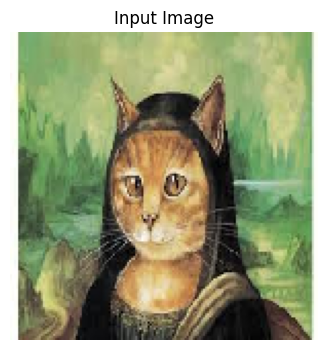

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted Class as: This is a DOG!


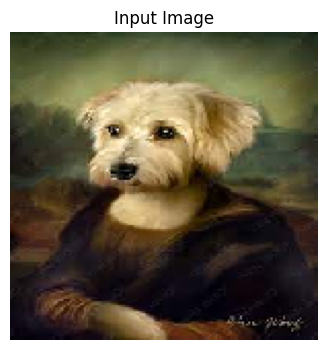

array([[1.]], dtype=float32)

In [43]:
url_test1_cat = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRHZMzqD0FsWs0Os0j5Xos1PvGmr79lWKL96w&s'
urt_test1_dog = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQw4tt3Zfl6NP6_l3JhHcM9OvHhaW9rq_cXFRjeYmTakhTA_0TC4b-6LTutrVRkXyhSq8E&usqp=CAU'
test_model_with_url(model_resnet, url_test1_cat, target_size=(150, 150), model_type="resnet50")
test_model_with_url(model_resnet, urt_test1_dog, target_size=(150, 150), model_type="resnet50")

## VGG16

In [44]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
# Freeze the layers of the pre-trained model
base_model.trainable = False

# Build your own classifier on top
x = base_model.output
x = Flatten()(x)
x = Dense(600, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Combine the base model and the new classifier
model_vgg16 = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model_vgg16.compile(optimizer=Adam(learning_rate=0.0003), loss='binary_crossentropy', metrics=['accuracy'])

Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 88ms/step - accuracy: 0.7947 - loss: 0.4517 - val_accuracy: 0.8977 - val_loss: 0.2443
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.8667 - val_loss: 0.1811
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 90ms/step - accuracy: 0.9012 - loss: 0.2356 - val_accuracy: 0.8992 - val_loss: 0.2337


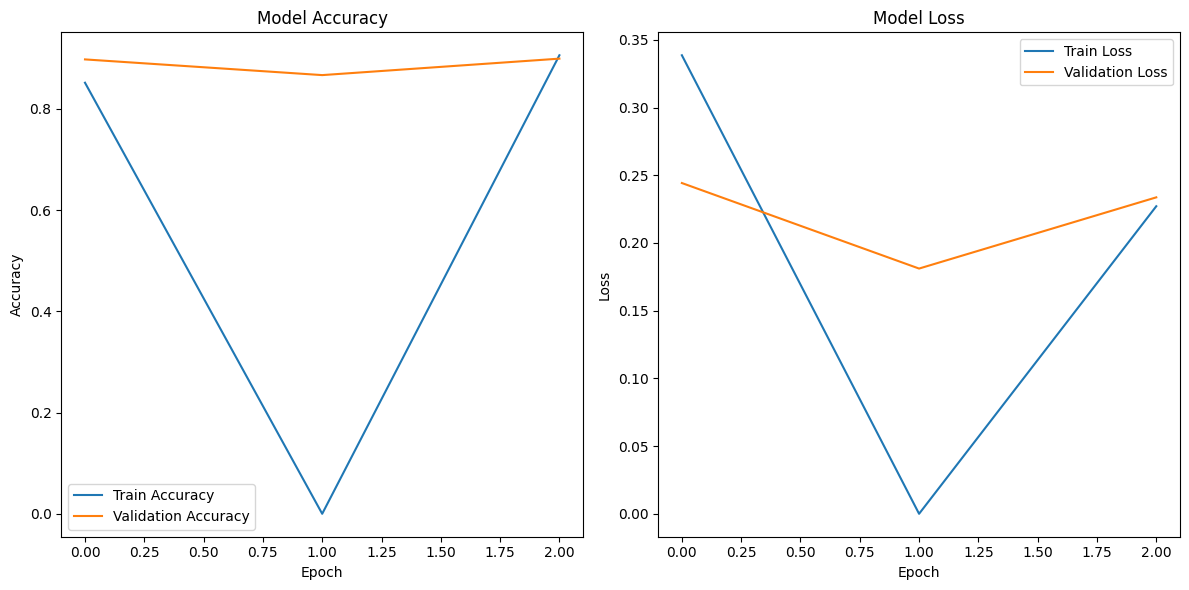

In [45]:
# Train the model and capture the history
history_vgg16 = model_vgg16.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    epochs=3,
    validation_data=test,
    validation_steps=test.samples // test.batch_size
)

# Plotting training & validation accuracy
plt.figure(figsize=(12, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_vgg16.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='best')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_vgg16.history['loss'], label='Train Loss')
plt.plot(history_vgg16.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')

# Show the plot
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Predicted Class as: Thist is a Cat


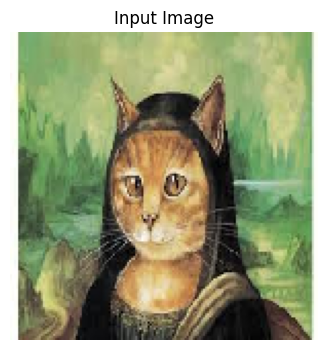

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted Class as: This is a DOG!


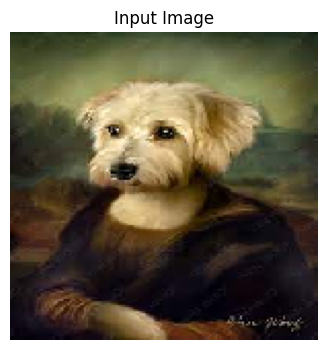

array([[1.]], dtype=float32)

In [48]:
url_test1_cat = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRHZMzqD0FsWs0Os0j5Xos1PvGmr79lWKL96w&s'
urt_test1_dog = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQw4tt3Zfl6NP6_l3JhHcM9OvHhaW9rq_cXFRjeYmTakhTA_0TC4b-6LTutrVRkXyhSq8E&usqp=CAU'
test_model_with_url(model_vgg16, url_test1_cat, target_size=(150, 150), model_type="vgg16")
test_model_with_url(model_vgg16, urt_test1_dog, target_size=(150, 150), model_type="vgg16")

# Comparative

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step


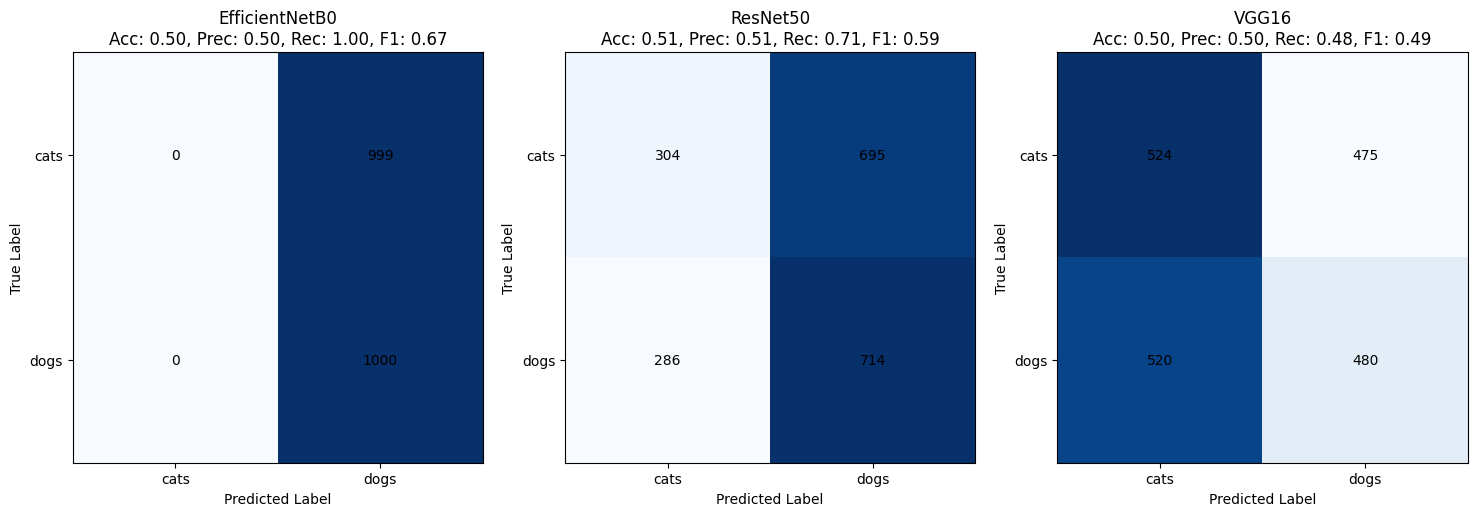

In [52]:
models = [model, model_resnet, model_vgg16]
model_names = ["EfficientNetB0", "ResNet50", "VGG16"]

# Evaluate models and plot confusion matrices
evaluate_models_on_same_plot(models, model_names, test)